In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import math

In [2]:
# the start and end date
start_date = dt.datetime(2020, 4, 1)
end_date = dt.datetime(2023, 4, 1)

# loading from yahoo finance
data = yf.download('GOOGL', start_date, end_date)

pd.set_option('display.max_row', 4)
pd.set_option('display.max_columns', 5)
print(data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL     GOOGL
Date                                                                
2020-04-01   54.653286   56.008090   54.226315   55.739311  51970000
2020-04-02   55.393677   55.678323   54.208473   54.549155  56410000
...                ...         ...         ...         ...       ...
2023-03-30  100.062981  100.330772   98.962079  100.082821  33086200
2023-03-31  102.879684  103.038369  100.211733  100.469604  36863400

[756 rows x 5 columns]


In [3]:
# setting 80% data for tarining
training_data_len = math.ceil(len(data) * 0.8)
training_data_len
# training_data = data[:training_data_len]
# splitting the data set
train_data = data[:training_data_len].iloc[:, :4]
test_data = data[training_data_len:].iloc[:, :4]
print (train_data.shape , test_data.shape)



(605, 4) (151, 4)


In [ ]:
# selecting open price value
dataset_train = train_data.Open.values
# reshaping 1d to 2d array

dataset_train = np.reshape(dataset_train,(-1, 1))
dataset_train.shape


(605, 1)

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# scaling the data
scaled_train = scaler.fit_transform(dataset_train)
print(scaled_train[:5])

[[0.00493676]
 [0.01277797]
 [0.        ]
 [0.04752452]
 [0.04719364]]


In [6]:
# selecting open price value
dataset_test = test_data.Open.values
# reshaping 1d to 2d array
dataset_test = np.reshape(dataset_test,(-1, 1))
# normalizing values between 0 and 1
scaled_test = scaler.fit_transform(dataset_test)
print(*scaled_test[:5])


[0.98362897] [1.] [0.83867618] [0.84481568] [0.86118698]


In [7]:
X_train = []
y_train = []
for i in range(50, len(scaled_train)):
    X_train.append(scaled_train[i-50:i, 0])
    y_train.append(scaled_train[i, 0])
    if i <= 51:
        print(X_train)
        print(y_train)
        print()

[array([0.00493676, 0.01277797, 0.        , 0.04752452, 0.04719364,
       0.06002934, 0.05980346, 0.06182019, 0.09061121, 0.08644645,
       0.08651468, 0.09784306, 0.08846843, 0.06273929, 0.08702938,
       0.09373082, 0.09658266, 0.09356801, 0.07346894, 0.13102463,
       0.13339837, 0.11796838, 0.12089892, 0.13461676, 0.13273153,
       0.14525732, 0.15316668, 0.16327663, 0.148356  , 0.13425453,
       0.13873449, 0.1472425 , 0.15360801, 0.14794627, 0.16620192,
       0.16493618, 0.16834466, 0.17261446, 0.17204183, 0.17097074,
       0.17899556, 0.17970458, 0.18361191, 0.18200504, 0.16890137,
       0.18240937, 0.18662131, 0.18874304, 0.19537099, 0.16238896])]
[np.float64(0.16817667231755606)]

[array([0.00493676, 0.01277797, 0.        , 0.04752452, 0.04719364,
       0.06002934, 0.05980346, 0.06182019, 0.09061121, 0.08644645,
       0.08651468, 0.09784306, 0.08846843, 0.06273929, 0.08702938,
       0.09373082, 0.09658266, 0.09356801, 0.07346894, 0.13102463,
       0.13339837, 0.11

In [8]:
X_test = []
Y_test = []
for i  in range(50, len(scaled_test)):
  X_test.append(scaled_test[i-50 : i ,0])
  Y_test.append(scaled_test[ i ,0])

In [9]:
# the data is converted to numpy array
X_train,y_train = np.array(X_train),np.array(y_train)

# reshaping
X_train_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
y_train_train = np.reshape(y_train,(y_train.shape[0],1))
print("X_train : ",X_train_train.shape , "y_train : ",y_train.shape)

X_train :  (555, 50, 1) y_train :  (555,)


In [10]:
# the data is converted to numpy array
X_test,Y_test = np.array(X_test),np.array(Y_test)

# reshaping
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
Y_test = np.reshape(Y_test,(Y_test.shape[0],1))
print("X_test : ",X_test.shape , "Y_test : ",Y_test.shape)


X_test :  (101, 50, 1) Y_test :  (101, 1)


In [11]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.layers import SimpleRNN
from keras.layers import Dropout
from keras.layers import GRU, Bidirectional
from keras.optimizers import SGD
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [17]:
# intializing the RNN
regressor = Sequential()

# add RNN layers 
regressor.add(SimpleRNN(units=50,
                        activation='tanh',
                        return_sequences=True,
                        input_shape = (X_train.shape[1],1)))
regressor.add(Dropout(.2))


regressor.add(SimpleRNN(units=50,
                      activation='tanh' ,
                       return_sequences= True ))

regressor.add(SimpleRNN(units=50,
                        activation='tanh',
                        return_sequences=True))

regressor.add(SimpleRNN(units=50))

# adding the output layer

regressor.add(Dense(units= 1, activation='sigmoid'))

# compiling rnn

regressor.compile(optimizer=SGD(learning_rate=0.01,
                                decay = 1e-6,
                                momentum=.9,
                                nesterov=True),
                                loss='mean_squared_error')

# fitting the model
regressor.fit(X_train,y_train,epochs=20,batch_size=2)
regressor.summary()

# GRU
regressorGRU = Sequential()

# GRU layer
regressorGRU.add(GRU(units= 50,
                     return_sequences=True,
                     input_shape = (X_train.shape[1],1),
                     activation='tanh'))
regressorGRU.add(Dropout(.2))

regressorGRU.add(GRU(units=50,
                     return_sequences=True,
                     activation='tanh'))
regressorGRU.add(GRU(units=50,
                     return_sequences=True,
                     activation='tanh'))
regressorGRU.add(GRU(units=50,
                     activation='tanh'))

# output layer

regressorGRU.add(Dense(units=1,
                       activation='relu'))

# compiling the RNN
regressorGRU.compile(optimizer=SGD(learning_rate=.01,
                                   decay = 1e-7,
                                   momentum=.9,
                                   nesterov=False),
                                   loss = 'mean_squared_error')


# fitting the data 
regressorGRU.fit(X_train,y_train,epochs=20,batch_size=1)
regressorGRU.summary()

# lstm

regressorLSTM = Sequential()

regressorLSTM.add(LSTM(units=50,
                       return_sequences=True,
                       input_shape = (X_train.shape[1],1)))
regressorLSTM.add(LSTM(units=50,
                       return_sequences=True))
regressorLSTM.add(Dense(25))
regressorLSTM.add(Dense(1))

regressorLSTM.compile(optimizer="adam", loss = 'mean_squared_error',
                      metrics = ['accuracy'])

regressorLSTM.fit(X_train,y_train,batch_size=1,epochs=20)
regressorLSTM.summary()




c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.0523
Epoch 2/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0692
Epoch 3/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0707
Epoch 4/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0672
Epoch 5/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0664
Epoch 6/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0617
Epoch 7/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0642
Epoch 8/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0428
Epoch 9/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0085
Epoch 10/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0062
Epoch 11/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0057
Epoch 12/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0060
Epoch 13/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0061
Epoch 14/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0050
Epoch 15/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 7

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 50, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,604 (139.08 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50, 25)         │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50, 1)          │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

In [18]:
# prediction wih X_train
# scaling back from 0-1 to original
y_RNN = regressor.predict(X_test)
y_RNN_O = scaler.inverse_transform(y_RNN)
# GRU
y_GRU = regressorGRU.predict(X_test)
y_GRU_O = scaler.inverse_transform(y_GRU)

# lstm
y_LSTM = regressorLSTM.predict(X_test)
y_LSTM_O = scaler.inverse_transform(y_GRU)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000276BA2A9AB0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


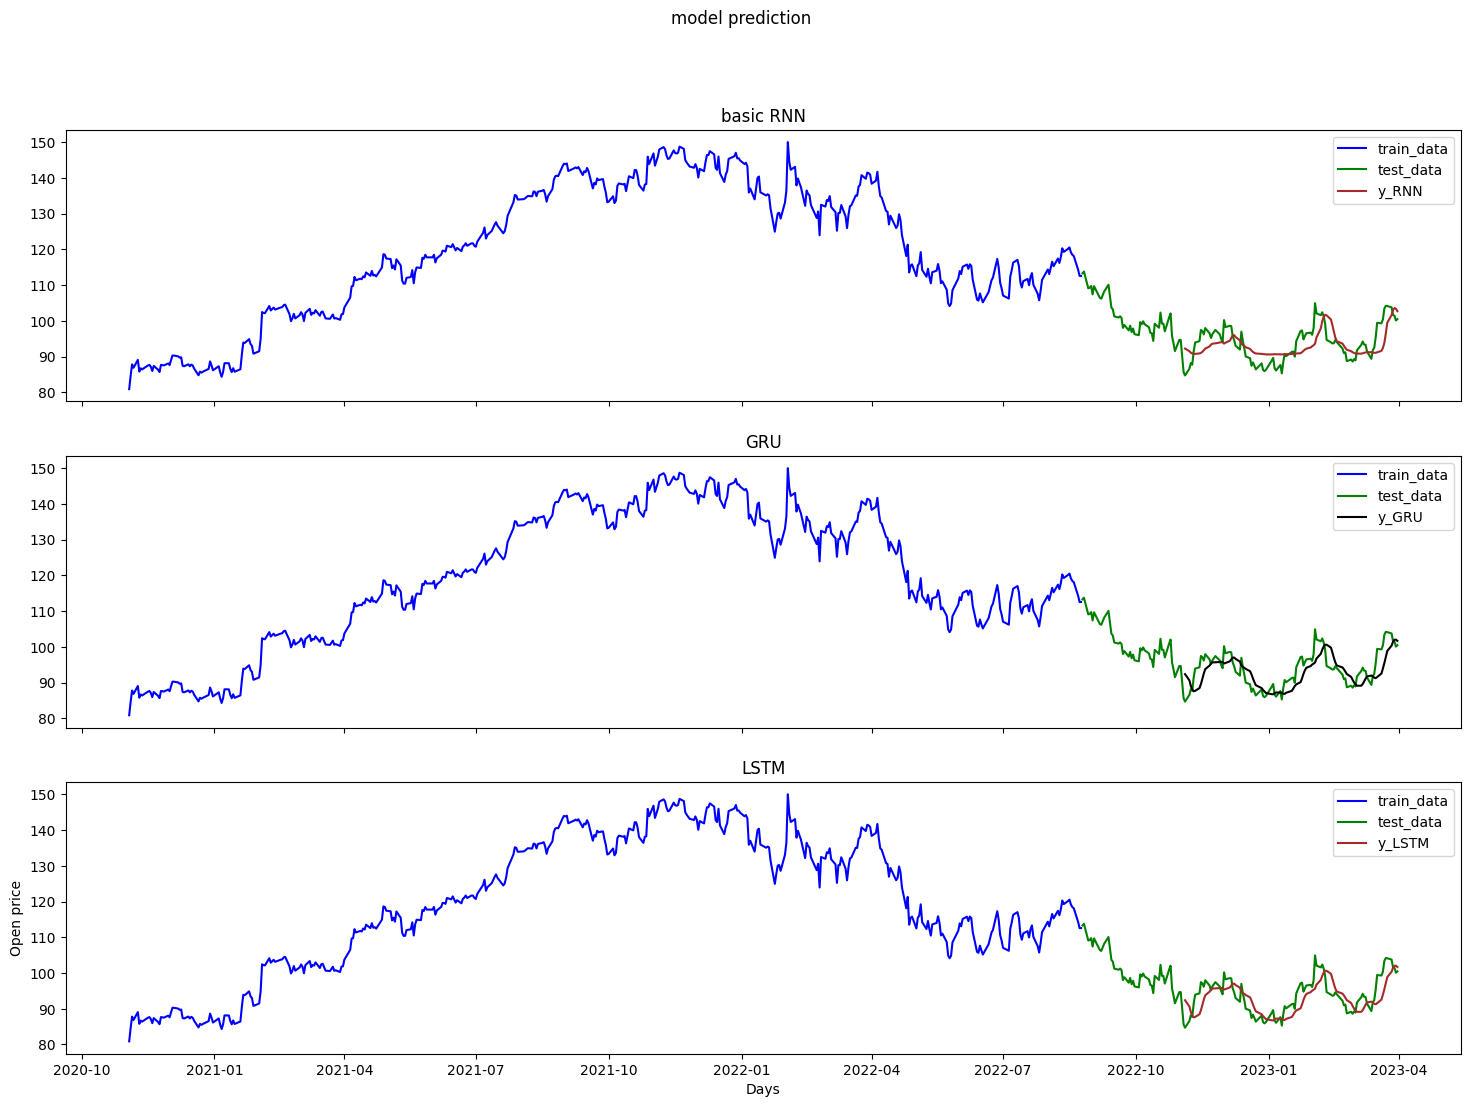

In [19]:
fig,axs = plt.subplots(3,figsize = (18,12),sharex=True,sharey=True)
fig.suptitle('model prediction')
# plot for RNN prediction
axs[0].plot(train_data.index[150:],train_data.Open[150:],label = "train_data" , color ='b')
axs[0].plot(test_data.index, test_data.Open, label = "test_data", color = 'g')
axs[0].plot(test_data.index[50:],y_RNN_O,label = "y_RNN",color = 'brown')
axs[0].legend()
axs[0].title.set_text('basic RNN')
# plot
axs[1].plot(train_data.index[150:],train_data.Open[150:],label = "train_data" , color ='b')
axs[1].plot(test_data.index, test_data.Open, label = "test_data", color = 'g')
axs[1].plot(test_data.index[50:],y_GRU_O,label = "y_GRU",color = 'black')
axs[1].legend()
axs[1].title.set_text('GRU')


# LSTM

axs[2].plot(train_data.index[150:],train_data.Open[150:],label = "train_data" , color ='b')
axs[2].plot(test_data.index, test_data.Open, label = "test_data", color = 'g')
axs[2].plot(test_data.index[50:],y_GRU_O,label = "y_LSTM",color = 'brown')
axs[2].legend()
axs[2].title.set_text('LSTM')

plt.xlabel("Days")
plt.ylabel("Open price")

plt.show()

